> **Autonomous Ride-Hailing Korea Market Analysis**
>
> A plan-style analysis of the autonomous ride-hailing opportunity in Korea, using 2025 public taxi operations data from the Ministry of Land, Infrastructure and Transport (국토교통부). Covers five sections: (1) Purpose, (2) Opportunity — TAM→SAM→SOM market sizing with demand pattern analysis, (3) Go-to-Market — phased deployment strategy grounded in hub-level seasonality, (4) Price Logic — 3-phase fare progression, and (5) Open Questions.

In [0]:
# pip install requests pandas openpyxl

In [0]:
import os
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from IPython.display import display, Markdown
import seaborn as sns

In [0]:
# ==========================================
# 0. Assumptions & Parameters
# ==========================================

# ---- Data source ----
base_dir = '/Workspace/Users/jeonghyeon.lee/Drafts/personal project/raw data'
prefix = '국토교통부_택시운행정보관리시스템_택시운영현황_격자별 영업통계_2025'  # grid-level stats file prefix
sum_file_keyword = '영업_2025_합계'                 # annual totals file keyword
avg_file_keyword = '영업_2025_1대당 1일평균'          # per-vehicle daily average file keyword

# ---- Target hubs: grid ID -> hub name ----
target_grids = {
    '다사014078': 'Incheon Airport T1',
    '다사011083': 'Incheon Airport T2',
    '마라080162': 'Gangnam Station',
    '다사106101': 'Hongdae Station',
    '다사116089': 'Yeouido Station',
    '마마003130': 'Seoul Station',
    '마라078158': 'Pangyo Station',
}

# ---- TAM -> SAM -> SOM scenarios ----
scenarios = ['Low', 'Base', 'High']
addressable_share = {'Low': 0.10, 'Base': 0.20, 'High': 0.35}   # SAM = TAM x this
pilot_fleet_size = {'Low': 100, 'Base': 300, 'High': 500}       # fleet size (also used for Phase 1/2/3 rollout)
trips_per_veh_day = {'Low': 10, 'Base': 15, 'High': 20}
operating_days_y1 = {'Low': 270, 'Base': 300, 'High': 330}

# ---- Pricing ----
phase1_fare = 4000    # Phase 1 fare per trip (KRW)
phase2_fare = 4800    # Phase 2 fare per trip (KRW) = Seoul standard rate
phase1_discount_pct = round((1 - phase1_fare / phase2_fare) * 100, 1)  # auto-calculated
exchange_rate = 1350  # KRW per USD
phase2_surge_range = (1.1, 1.3)  # Phase 2 peak surge multiplier range

print(f"Assumptions loaded (Phase 1 discount: {phase1_discount_pct}%)")


Assumptions loaded (Phase 1 discount: 16.7%)


# 1. Purpose

**Problem**: Korea's taxi industry faces a structural supply shortage — an aging driver workforce (average age 60+), declining new entrants, and rising urban mobility demand in the Seoul Capital Area (~25M population). During peak hours and in suburban corridors, wait times regularly exceed 15-20 minutes, creating a persistent service gap.

**Solution**: Autonomous ride-hailing offers a scalable, technology-driven alternative. By deploying self-driving vehicles on high-demand, well-mapped routes in the capital region, the service fills the supply gap without depending on new human drivers.

**For Whom**:
* **Phase 1 users** — Tech-savvy professionals, corporate travelers, and airport shuttle riders (predictable routes, controlled environments)
* **Phase 2 users** — General urban commuters in core Seoul districts (Gangnam, Hongdae, Yeouido)
* **Phase 3 users** — Mass-market commuters across the full capital corridor (Seoul ↔ Gyeonggi/Incheon)

# 2. Opportunity

We size the Korea autonomous ride-hailing opportunity using a **TAM → SAM → SOM** framework grounded in public taxi operation data from the Ministry of Land, Infrastructure and Transport (국토교통부). The approach:

1. **Macro market** — Total domestic taxi trip volume (national)
2. **TAM (Total Addressable Market)** — Capital Area annual trips (Seoul + Gyeonggi/Incheon) as the addressable geography
3. **SAM (Serviceable Available Market)** — Trips on routes suitable for autonomous operation (10-35% of TAM, scenario-dependent)
4. **SOM (Serviceable Obtainable Market)** — Year-1 achievable rides based on pilot fleet size, utilization, and operating days
5. **Revenue** — SOM × fare per trip, across pricing phases

All data is 2025 calendar year from the official taxi operations information management system.

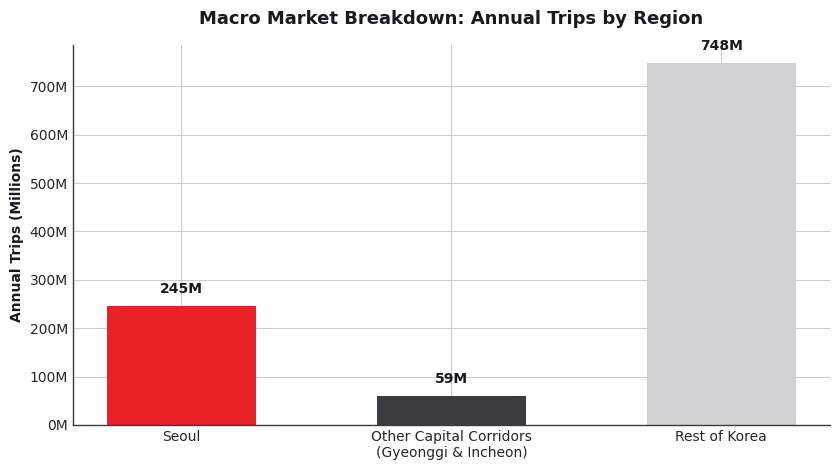

In [0]:
# ==========================================
# Setup & Macro Market Data
# ==========================================
BG_COLOR = "#FFFFFF"            # White
TEXT_MAIN = "#171A20"           # Dark Charcoal
PRIMARY_RED = "#E82127"         # Accent Red
ACCENT_GRAY = "#393C41"         # Slate Gray
LIGHT_CARD_BG = "#F4F4F4"       # Minimal Light Gray
HIGHLIGHT_BG = "#FBEBEB"        # Light Red Tint

def format_km_dp2(val):
    if abs(val) >= 1e6:
        return f"{val / 1e6:.2f}M"
    elif abs(val) >= 1e3:
        return f"{int(round(val / 1e3))}K"
    else:
        return f"{int(round(val))}"

# ==========================================
# Data Load (Annual Summary)
# ==========================================
files = os.listdir(base_dir)
file_sum_name = [f for f in files if sum_file_keyword in unicodedata.normalize('NFC', f) and f.endswith('.csv')][0]
file_avg_name = [f for f in files if avg_file_keyword in unicodedata.normalize('NFC', f) and f.endswith('.csv')][0]

path_sum = os.path.join(base_dir, file_sum_name)
path_avg = os.path.join(base_dir, file_avg_name)

def load_csv_safely(file_path):
    try:
        return pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding='cp949')

df_sum = load_csv_safely(path_sum)
df_avg = load_csv_safely(path_avg)

nat_annual_trips = df_sum['영엽횟수(회)'].sum()
seoul_df_sum = df_sum[df_sum['지자체명'] == '서울특별시']
seoul_annual_trips = seoul_df_sum['영엽횟수(회)'].sum()
seoul_share_nat = seoul_annual_trips / nat_annual_trips

seoul_df_avg = df_avg[df_avg['지자체명'] == '서울특별시']
seoul_avg_active_fleet = seoul_df_sum['영업대수'].mean()

# ==========================================
# Regional Breakdown Chart
# ==========================================
capital_df_sum = df_sum[df_sum['지자체명'].isin(['경기도', '인천광역시'])]
other_capital_trips = capital_df_sum['영엽횟수(회)'].sum()
rest_korea_trips = nat_annual_trips - seoul_annual_trips - other_capital_trips

regional_breakdown = pd.DataFrame({
    'Region': ['Seoul', 'Other Capital Corridors\n(Gyeonggi & Incheon)', 'Rest of Korea'],
    'Trips': [seoul_annual_trips, other_capital_trips, rest_korea_trips]
})
regional_breakdown['Share (%)'] = (regional_breakdown['Trips'] / nat_annual_trips) * 100

fig1, ax1 = plt.subplots(figsize=(8.5, 4.8), facecolor=BG_COLOR)
ax1.set_facecolor(BG_COLOR)

bars = ax1.bar(
    regional_breakdown['Region'], 
    regional_breakdown['Trips'] * 1e-6, 
    color=[PRIMARY_RED, ACCENT_GRAY, '#D0D1D2'], 
    width=0.55
)

ax1.set_title('Macro Market Breakdown: Annual Trips by Region', fontsize=13, fontweight='bold', color=TEXT_MAIN, pad=15)
ax1.set_ylabel('Annual Trips (Millions)', fontsize=10, fontweight='bold', color=TEXT_MAIN)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(round(x))}M'))

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(ACCENT_GRAY)
ax1.spines['bottom'].set_color(ACCENT_GRAY)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (nat_annual_trips * 1e-6 * 0.02), f'{int(round(yval))}M', ha='center', va='bottom', fontweight='bold', color=TEXT_MAIN)

plt.tight_layout()
plt.savefig('macro_market_breakdown.png', dpi=300)
plt.show()


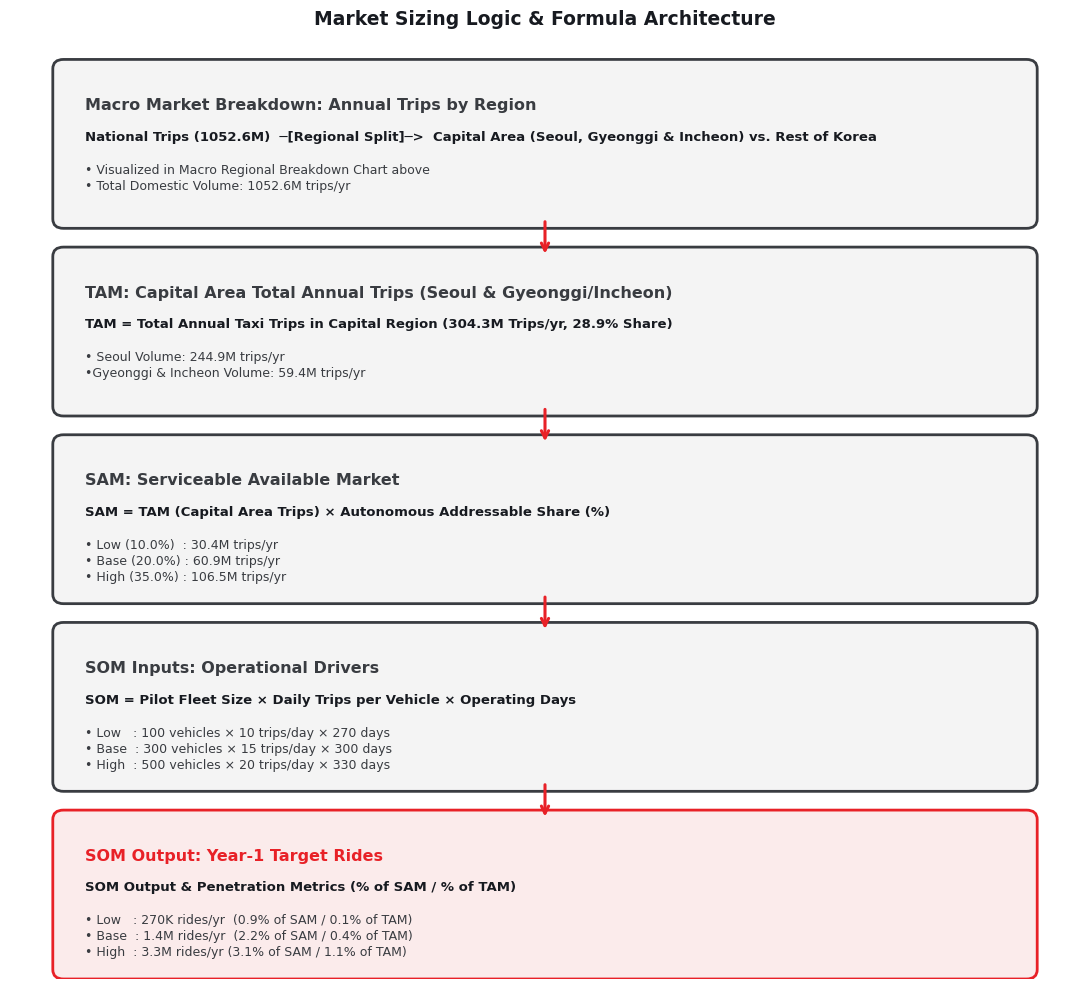

In [0]:
# ==========================================
# 3. Market Sizing Calculations (TAM -> SAM -> SOM)
# ==========================================

# Override: 1 dp for M values, 1 dp for share %
def format_km_dp2(val):
    if abs(val) >= 1e6:
        return f"{val / 1e6:.1f}M"
    elif abs(val) >= 1e3:
        return f"{int(round(val / 1e3))}K"
    else:
        return f"{int(round(val))}"
capital_total_trips = seoul_annual_trips + other_capital_trips
capital_share_nat = capital_total_trips / nat_annual_trips

tam_trips = {s: capital_total_trips for s in scenarios}
sam_trips = {s: tam_trips[s] * addressable_share[s] for s in scenarios}

som_rides = {s: pilot_fleet_size[s] * trips_per_veh_day[s] * operating_days_y1[s] for s in scenarios}
som_pct_sam = {s: som_rides[s] / sam_trips[s] for s in scenarios}
som_pct_tam = {s: som_rides[s] / tam_trips[s] for s in scenarios}

# ==========================================
# Formula Architecture Diagram
# ==========================================
fig2, ax2 = plt.subplots(figsize=(11, 10), facecolor=BG_COLOR)
ax2.set_facecolor(BG_COLOR)
ax2.axis('off')

boxes = [
    {"x": 0.05, "y": 0.81, "w": 0.90, "h": 0.16, 
     "title": "Macro Market Breakdown: Annual Trips by Region",
     "formula": f"National Trips ({format_km_dp2(nat_annual_trips)})  ─[Regional Split]─>  Capital Area (Seoul, Gyeonggi & Incheon) vs. Rest of Korea",
     "details": f"• Visualized in Macro Regional Breakdown Chart above\n• Total Domestic Volume: {format_km_dp2(nat_annual_trips)} trips/yr",
     "bg": LIGHT_CARD_BG, "border": ACCENT_GRAY, "title_color": ACCENT_GRAY},

    {"x": 0.05, "y": 0.61, "w": 0.90, "h": 0.16, 
     "title": "TAM: Capital Area Total Annual Trips (Seoul & Gyeonggi/Incheon)",
     "formula": f"TAM = Total Annual Taxi Trips in Capital Region ({format_km_dp2(capital_total_trips)} Trips/yr, {capital_share_nat*100:.1f}% Share)",
     "details": f"• Seoul Volume: {format_km_dp2(seoul_annual_trips)} trips/yr\n•Gyeonggi & Incheon Volume: {format_km_dp2(other_capital_trips)} trips/yr",
     "bg": LIGHT_CARD_BG, "border": ACCENT_GRAY, "title_color": ACCENT_GRAY},
    
    {"x": 0.05, "y": 0.41, "w": 0.90, "h": 0.16, 
     "title": "SAM: Serviceable Available Market",
     "formula": "SAM = TAM (Capital Area Trips) × Autonomous Addressable Share (%)",
     "details": f"• Low ({addressable_share['Low']*100:.1f}%)  : {format_km_dp2(sam_trips['Low'])} trips/yr\n• Base ({addressable_share['Base']*100:.1f}%) : {format_km_dp2(sam_trips['Base'])} trips/yr\n• High ({addressable_share['High']*100:.1f}%) : {format_km_dp2(sam_trips['High'])} trips/yr",
     "bg": LIGHT_CARD_BG, "border": ACCENT_GRAY, "title_color": ACCENT_GRAY},

    {"x": 0.05, "y": 0.21, "w": 0.90, "h": 0.16, 
     "title": "SOM Inputs: Operational Drivers",
     "formula": "SOM = Pilot Fleet Size × Daily Trips per Vehicle × Operating Days",
     "details": f"• Low   : {pilot_fleet_size['Low']} vehicles × {trips_per_veh_day['Low']} trips/day × {operating_days_y1['Low']} days\n• Base  : {pilot_fleet_size['Base']} vehicles × {trips_per_veh_day['Base']} trips/day × {operating_days_y1['Base']} days\n• High  : {pilot_fleet_size['High']} vehicles × {trips_per_veh_day['High']} trips/day × {operating_days_y1['High']} days",
     "bg": LIGHT_CARD_BG, "border": ACCENT_GRAY, "title_color": ACCENT_GRAY},

    {"x": 0.05, "y": 0.01, "w": 0.90, "h": 0.16, 
     "title": "SOM Output: Year-1 Target Rides",
     "formula": "SOM Output & Penetration Metrics (% of SAM / % of TAM)",
     "details": f"• Low   : {format_km_dp2(som_rides['Low'])} rides/yr  ({som_pct_sam['Low']*100:.1f}% of SAM / {som_pct_tam['Low']*100:.1f}% of TAM)\n• Base  : {format_km_dp2(som_rides['Base'])} rides/yr  ({som_pct_sam['Base']*100:.1f}% of SAM / {som_pct_tam['Base']*100:.1f}% of TAM)\n• High  : {format_km_dp2(som_rides['High'])} rides/yr ({som_pct_sam['High']*100:.1f}% of SAM / {som_pct_tam['High']*100:.1f}% of TAM)",
     "bg": HIGHLIGHT_BG, "border": PRIMARY_RED, "title_color": PRIMARY_RED}
]

for box in boxes:
    patch = mpatches.FancyBboxPatch((box["x"], box["y"]), box["w"], box["h"], 
                                    boxstyle="round,pad=0.01", facecolor=box["bg"], edgecolor=box["border"], linewidth=2)
    ax2.add_patch(patch)
    ax2.text(box["x"] + 0.02, box["y"] + box["h"] - 0.03, box["title"], fontsize=11.5, fontweight='bold', color=box["title_color"], va='top')
    ax2.text(box["x"] + 0.02, box["y"] + box["h"] - 0.065, box["formula"], fontsize=9.5, fontweight='bold', color=TEXT_MAIN, va='top')
    ax2.text(box["x"] + 0.02, box["y"] + box["h"] - 0.10, box["details"], fontsize=9.0, color=ACCENT_GRAY, va='top', linespacing=1.3)

arrow_style = dict(arrowstyle="->", color=PRIMARY_RED, lw=2.2, mutation_scale=13)
ax2.annotate("", xy=(0.5, 0.77), xytext=(0.5, 0.81), arrowprops=arrow_style)
ax2.annotate("", xy=(0.5, 0.57), xytext=(0.5, 0.61), arrowprops=arrow_style)
ax2.annotate("", xy=(0.5, 0.37), xytext=(0.5, 0.41), arrowprops=arrow_style)
ax2.annotate("", xy=(0.5, 0.17), xytext=(0.5, 0.21), arrowprops=arrow_style)

plt.title("Market Sizing Logic & Formula Architecture", fontsize=13.5, fontweight='bold', color=TEXT_MAIN, pad=12)
plt.tight_layout()
plt.savefig('market_sizing_architecture.png', dpi=300, bbox_inches='tight')
plt.show()


In [0]:
# ==========================================
# Market Sizing & Revenue Integration
# ==========================================

def format_revenue(krw_amount, dp=1):
    billion_krw = krw_amount / 1e9
    billion_won = krw_amount / 1e8  # 억 원
    usd_million = (krw_amount / exchange_rate) / 1e6
    return f"{billion_krw:,.{dp}f}B KRW ({billion_won:,.{dp}f}억 원, ${usd_million:,.{dp}f}M)"

# Revenue across pricing phases
tam_revenue = {s: tam_trips[s] * phase2_fare for s in scenarios}
sam_revenue = {s: sam_trips[s] * phase2_fare for s in scenarios}
som_revenue_p1 = {s: som_rides[s] * phase1_fare for s in scenarios}
som_revenue_p2 = {s: som_rides[s] * phase2_fare for s in scenarios}

df_market_sizing = pd.DataFrame({
    "Category / Variable": [
        "A. Macro Market (National Total Trips)",
        "B. TAM (Capital Area Annual Trips)",
        "   TAM Revenue Potential (Phase 2 pricing)",
        "C. Addressable Share (%)",
        "D. SAM (Autonomous Addressable Trips)",
        "   SAM Revenue Potential",
        "E1. Pilot Fleet Size (Vehicles)",
        "E2. Trips / Vehicle / Day",
        "E3. Operating Days (Year 1)",
        "F1. SOM (Year-1 Target Rides)",
        f"F2-1. SOM Revenue (Phase 1: {phase1_fare:,} KRW)",
        f"F2-2. SOM Revenue (Phase 2: {phase2_fare:,} KRW)",
        "F3. SOM Share of SAM (%)",
        "F4. SOM Share of TAM (%)",
    ],
    "Low": [
        format_km_dp2(nat_annual_trips),
        format_km_dp2(tam_trips['Low']),
        format_revenue(tam_revenue["Low"]),
        f"{addressable_share['Low']*100:.1f}%",
        format_km_dp2(sam_trips['Low']),
        format_revenue(sam_revenue["Low"]),
        f"{pilot_fleet_size['Low']}",
        f"{int(trips_per_veh_day['Low'])}",
        f"{operating_days_y1['Low']}",
        format_km_dp2(som_rides['Low']),
        format_revenue(som_revenue_p1["Low"]),
        format_revenue(som_revenue_p2["Low"]),
        f"{som_pct_sam['Low']*100:.1f}%",
        f"{som_pct_tam['Low']*100:.1f}%",
    ],
    "Base": [
        format_km_dp2(nat_annual_trips),
        format_km_dp2(tam_trips['Base']),
        format_revenue(tam_revenue["Base"]),
        f"{addressable_share['Base']*100:.1f}%",
        format_km_dp2(sam_trips['Base']),
        format_revenue(sam_revenue["Base"]),
        f"{pilot_fleet_size['Base']}",
        f"{int(trips_per_veh_day['Base'])}",
        f"{operating_days_y1['Base']}",
        format_km_dp2(som_rides['Base']),
        format_revenue(som_revenue_p1["Base"]),
        format_revenue(som_revenue_p2["Base"]),
        f"{som_pct_sam['Base']*100:.1f}%",
        f"{som_pct_tam['Base']*100:.1f}%",
    ],
    "High": [
        format_km_dp2(nat_annual_trips),
        format_km_dp2(tam_trips['High']),
        format_revenue(tam_revenue["High"]),
        f"{addressable_share['High']*100:.1f}%",
        format_km_dp2(sam_trips['High']),
        format_revenue(sam_revenue["High"]),
        f"{pilot_fleet_size['High']}",
        f"{int(trips_per_veh_day['High'])}",
        f"{operating_days_y1['High']}",
        format_km_dp2(som_rides['High']),
        format_revenue(som_revenue_p1["High"]),
        format_revenue(som_revenue_p2["High"]),
        f"{som_pct_sam['High']*100:.1f}%",
        f"{som_pct_tam['High']*100:.1f}%",
    ],
})

print("=== Market Sizing & Revenue Integration ===")
display(df_market_sizing)

=== Market Sizing & Revenue Integration ===


,Category / Variable,Low,Base,High
0,A. Macro Market (National Total Trips),1052.6M,1052.6M,1052.6M
1,B. TAM (Capital Area Annual Trips),304.3M,304.3M,304.3M
2,TAM Revenue Potential (Phase 2 pricing),"1,460.7B KRW (14,606.9억 원, $1,082.0M)","1,460.7B KRW (14,606.9억 원, $1,082.0M)","1,460.7B KRW (14,606.9억 원, $1,082.0M)"
3,C. Addressable Share (%),10.0%,20.0%,35.0%
4,D. SAM (Autonomous Addressable Trips),30.4M,60.9M,106.5M
5,SAM Revenue Potential,"146.1B KRW (1,460.7억 원, $108.2M)","292.1B KRW (2,921.4억 원, $216.4M)","511.2B KRW (5,112.4억 원, $378.7M)"
6,E1. Pilot Fleet Size (Vehicles),100,300,500
7,E2. Trips / Vehicle / Day,10,15,20
8,E3. Operating Days (Year 1),270,300,330
9,F1. SOM (Year-1 Target Rides),270K,1.4M,3.3M


=== Market Size in USD ===


,Metric,Low,Base,High
0,TAM revenue potential,"$1,082.0M","$1,082.0M","$1,082.0M"
1,SAM revenue potential,$108.2M,$216.4M,$378.7M
2,SOM revenue (Phase 1 pricing),$0.8M,$4.0M,$9.8M
3,SOM revenue (Phase 2 pricing),$1.0M,$4.8M,$11.7M


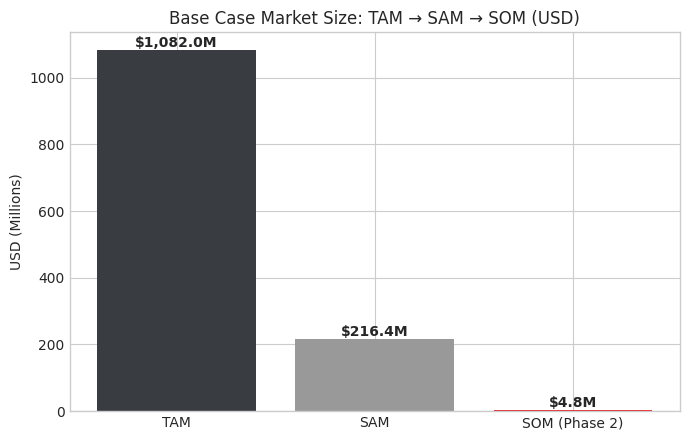

In [0]:
# ==========================================
# Market Size in USD
# ==========================================
def to_usd(krw_amount):
    return krw_amount / exchange_rate

df_usd_summary = pd.DataFrame({
    "Metric": [
        "TAM revenue potential",
        "SAM revenue potential",
        "SOM revenue (Phase 1 pricing)",
        "SOM revenue (Phase 2 pricing)",
    ],
    "Low": [
        f"${to_usd(tam_revenue['Low'])/1e6:,.1f}M",
        f"${to_usd(sam_revenue['Low'])/1e6:,.1f}M",
        f"${to_usd(som_revenue_p1['Low'])/1e6:,.1f}M",
        f"${to_usd(som_revenue_p2['Low'])/1e6:,.1f}M",
    ],
    "Base": [
        f"${to_usd(tam_revenue['Base'])/1e6:,.1f}M",
        f"${to_usd(sam_revenue['Base'])/1e6:,.1f}M",
        f"${to_usd(som_revenue_p1['Base'])/1e6:,.1f}M",
        f"${to_usd(som_revenue_p2['Base'])/1e6:,.1f}M",
    ],
    "High": [
        f"${to_usd(tam_revenue['High'])/1e6:,.1f}M",
        f"${to_usd(sam_revenue['High'])/1e6:,.1f}M",
        f"${to_usd(som_revenue_p1['High'])/1e6:,.1f}M",
        f"${to_usd(som_revenue_p2['High'])/1e6:,.1f}M",
    ],
})

print("=== Market Size in USD ===")
display(df_usd_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ['TAM', 'SAM', 'SOM (Phase 2)']
values = [
    to_usd(tam_revenue['Base']) / 1e6,
    to_usd(sam_revenue['Base']) / 1e6,
    to_usd(som_revenue_p2['Base']) / 1e6,
]
ax.bar(labels, values, color=[ACCENT_GRAY, '#999999', PRIMARY_RED])
ax.set_ylabel('USD (Millions)')
ax.set_title('Base Case Market Size: TAM \u2192 SAM \u2192 SOM (USD)')
for i, v in enumerate(values):
    ax.text(i, v, f'${v:,.1f}M', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('market_size_usd.png', dpi=300)
plt.show()

# 3. Go-to-Market / Annual Plan Sketch

The deployment strategy follows a **3-phase geographic and audience expansion**, informed by the demand patterns and hub seasonality analysis above. Each phase targets a specific user segment, corridor, and fleet scale — building operational confidence before broadening.

Pricing is anchored to the **Seoul standard taxi base fare (4,800 KRW)** — the most recognizable reference point for Korean consumers. The 3-phase pricing model below balances adoption incentives against unit economics.

In [0]:
# ==========================================
# Phased Rollout & Deployment Strategy
# Generated from the Assumptions section above.
# ==========================================
# ==========================================
# Compute hub-level metrics from demand data
# ==========================================
hub_avg = piv_trips.mean().round(0).astype(int)
fmt_k = lambda v: f"{v/1e3:.0f}K"

# Average monthly volumes per hub
vol_pangyo = fmt_k(hub_avg['Pangyo Station'])
vol_t1 = fmt_k(hub_avg['Incheon Airport T1'])
vol_t2 = fmt_k(hub_avg['Incheon Airport T2'])
vol_gangnam = fmt_k(hub_avg['Gangnam Station'])
vol_hongdae = fmt_k(hub_avg['Hongdae Station'])
vol_yeouido = fmt_k(hub_avg['Yeouido Station'])
vol_seoul = fmt_k(hub_avg['Seoul Station'])
vol_other_capital = format_km_dp2(other_capital_trips)

# Seasonality indices from heatmap
hs = df_hub_seasonality
_mo = lambda ym: ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][int(ym[-2:])-1]

s_pangyo_range = f"{hs['Pangyo Station'].min():.2f}\u2013{hs['Pangyo Station'].max():.2f}"
s_t2_peak = f"{hs['Incheon Airport T2'].max():.2f}"
s_airport_winter = f"{min(hs.loc['2025-01','Incheon Airport T1'], hs.loc['2025-02','Incheon Airport T2']):.2f}"
s_gangnam_peak = f"{hs['Gangnam Station'].max():.2f}"
s_gangnam_peak_mo = _mo(hs['Gangnam Station'].idxmax())
s_hongdae_peak = f"{hs['Hongdae Station'].max():.2f}"
s_hongdae_peak_mo = _mo(hs['Hongdae Station'].idxmax())
s_yeouido_mar = f"{hs.loc['2025-03','Yeouido Station']:.2f}"
s_yeouido_sep = f"{hs.loc['2025-09','Yeouido Station']:.2f}"
s_seoul_range = f"{hs['Seoul Station'].min():.2f}\u2013{hs['Seoul Station'].max():.2f}"
s_nat_dec = f"{df_monthly_total[df_monthly_total['\ub144\uc6d4']=='2025-12']['seasonality_index'].values[0]:.2f}"

_summer = hs.loc[['2025-07','2025-08'], ['Gangnam Station','Hongdae Station','Yeouido Station']].values.flatten()
s_phase2_summer = f"{_summer.min():.2f}\u2013{_summer.max():.2f}"

deployment_md = f"""

## Executive Summary
Deploying autonomous ride-hailing in the Seoul Capital Area requires balancing regulatory constraints, consumer adoption friction, and demand density. This roadmap is grounded in **actual 2025 taxi operation data** — hub-level demand volumes, monthly seasonality patterns, and geographic concentration — to dictate who gets access first, in what corridors, and how the service scales.

---

## Phase 1 — Controlled Launch (Months 0-6)
**Zones**: Pangyo Station + Incheon Airport T1/T2 | **Fleet**: {pilot_fleet_size['Low']} vehicles | **Fare**: {phase1_fare:,} KRW (-{phase1_discount_pct}%)

| | Pangyo Station | Incheon Airport T1/T2 |
| :--- | :--- | :--- |
| **Volume** | {vol_pangyo} trips/month | T1: {vol_t1}, T2: {vol_t2} trips/month |
| **Seasonality** | Stable year-round ({s_pangyo_range}) | Sharp Chuseok peak — T2 hits **{s_t2_peak}** in Oct |
| **Pros** | Tech-savvy riders (IT cluster), predictable commute patterns, low traffic complexity | Fixed origin-destination (terminal ↔ city), controlled road environments, high fare per trip (long distance) |
| **Cons** | Low volume limits revenue upside | Seasonal spikes require flexible fleet sizing; winter dip (Jan-Feb: {s_airport_winter}) |
| **Why first** | Low-risk proving ground for AV tech with tolerant early adopters | High-value corridor with simple routing; international travelers have prior AV exposure |

**Seasonality play**: Launch in **March-April** (demand rising from Feb trough) to build operational confidence before the summer peak.

---

## Phase 2 — Urban Expansion (Months 6-12)
**Zones**: Gangnam + Hongdae + Yeouido | **Fleet**: {pilot_fleet_size['Base']} vehicles | **Fare**: {phase2_fare:,} KRW (parity) + mild surge ({phase2_surge_range[0]}x-{phase2_surge_range[1]}x)

| | Gangnam Station | Hongdae Station | Yeouido Station |
| :--- | :--- | :--- | :--- |
| **Volume** | {vol_gangnam} trips/month (highest) | {vol_hongdae} trips/month | {vol_yeouido} trips/month |
| **Seasonality** | Peak {s_gangnam_peak_mo}: **{s_gangnam_peak}** | Peak {s_hongdae_peak_mo}: **{s_hongdae_peak}** | Volatile — Mar: **{s_yeouido_mar}**, Sep: **{s_yeouido_sep}** |
| **Pros** | Highest demand density, premium rider mix (business/entertainment) | Comparable volume to Gangnam, strong nightlife demand | Business district with regular commute demand |
| **Cons** | Complex traffic, narrow streets, high pedestrian density | Late-night demand requires extended hours (safety/regulatory risk) | Sharp Sep dip (0.91) tied to vacation season; lower weekend demand |
| **Why Phase 2** | Volume justifies fleet expansion; tech proven in Phase 1 | Complements Gangnam geographically; tests nightlife use case | Adds weekday commuter segment; tests B2B corporate accounts |

**Seasonality play**: Time the Phase 2 launch for **May-June** to capture the Jul-Aug summer peak ({s_phase2_summer} index) across all three hubs.

---

## Phase 3 — Full Commercialization (Months 12+)
**Zones**: Full capital corridor (Seoul ↔ Gyeonggi/Incheon) | **Fleet**: {pilot_fleet_size['High']}+ vehicles | **Model**: Subscriptions & passes

| | Seoul Station | Cross-corridor expansion |
| :--- | :--- | :--- |
| **Volume** | {vol_seoul} trips/month | Gyeonggi/Incheon: {vol_other_capital} annual trips |
| **Seasonality** | Steady ({s_seoul_range}) | Follows national pattern (Feb low, Jul-Dec high) |
| **Pros** | Major transit interchange — connects KTX/subway to last-mile; steady demand | Massive untapped volume; suburban corridors have simpler road conditions |
| **Cons** | Congested pickup zones around station; multi-modal coordination needed | Longer trip distances increase per-trip cost; sparse demand in off-peak areas |

**Retention mechanics**: Monthly commuting passes (Pangyo↔Gangnam, Airport↔Seoul), fixed-route shuttles, and tiered/premium options.

**Seasonal fleet balancing**: Use Oct airport surge (T2: {s_t2_peak}) and Dec year-end peak (national: {s_nat_dec}) to maximize utilization; redeploy vehicles from Yeouido (Sep dip: {s_yeouido_sep}) to airport routes during Chuseok.
"""

display(Markdown(deployment_md))




## Executive Summary
Deploying autonomous ride-hailing in the Seoul Capital Area requires balancing regulatory constraints, consumer adoption friction, and demand density. This roadmap is grounded in **actual 2025 taxi operation data** — hub-level demand volumes, monthly seasonality patterns, and geographic concentration — to dictate who gets access first, in what corridors, and how the service scales.

---

## Phase 1 — Controlled Launch (Months 0-6)
**Zones**: Pangyo Station + Incheon Airport T1/T2 | **Fleet**: 100 vehicles | **Fare**: 4,000 KRW (-16.7%)

| | Pangyo Station | Incheon Airport T1/T2 |
| :--- | :--- | :--- |
| **Volume** | 125K trips/month | T1: 103K, T2: 55K trips/month |
| **Seasonality** | Stable year-round (0.86–1.06) | Sharp Chuseok peak — T2 hits **1.24** in Oct |
| **Pros** | Tech-savvy riders (IT cluster), predictable commute patterns, low traffic complexity | Fixed origin-destination (terminal ↔ city), controlled road environments, high fare per trip (long distance) |
| **Cons** | Low volume limits revenue upside | Seasonal spikes require flexible fleet sizing; winter dip (Jan-Feb: 0.89) |
| **Why first** | Low-risk proving ground for AV tech with tolerant early adopters | High-value corridor with simple routing; international travelers have prior AV exposure |

**Seasonality play**: Launch in **March-April** (demand rising from Feb trough) to build operational confidence before the summer peak.

---

## Phase 2 — Urban Expansion (Months 6-12)
**Zones**: Gangnam + Hongdae + Yeouido | **Fleet**: 300 vehicles | **Fare**: 4,800 KRW (parity) + mild surge (1.1x-1.3x)

| | Gangnam Station | Hongdae Station | Yeouido Station |
| :--- | :--- | :--- | :--- |
| **Volume** | 193K trips/month (highest) | 195K trips/month | 123K trips/month |
| **Seasonality** | Peak Aug: **1.10** | Peak Aug: **1.08** | Volatile — Mar: **1.08**, Sep: **0.91** |
| **Pros** | Highest demand density, premium rider mix (business/entertainment) | Comparable volume to Gangnam, strong nightlife demand | Business district with regular commute demand |
| **Cons** | Complex traffic, narrow streets, high pedestrian density | Late-night demand requires extended hours (safety/regulatory risk) | Sharp Sep dip (0.91) tied to vacation season; lower weekend demand |
| **Why Phase 2** | Volume justifies fleet expansion; tech proven in Phase 1 | Complements Gangnam geographically; tests nightlife use case | Adds weekday commuter segment; tests B2B corporate accounts |

**Seasonality play**: Time the Phase 2 launch for **May-June** to capture the Jul-Aug summer peak (1.03–1.10 index) across all three hubs.

---

## Phase 3 — Full Commercialization (Months 12+)
**Zones**: Full capital corridor (Seoul ↔ Gyeonggi/Incheon) | **Fleet**: 500+ vehicles | **Model**: Subscriptions & passes

| | Seoul Station | Cross-corridor expansion |
| :--- | :--- | :--- |
| **Volume** | 178K trips/month | Gyeonggi/Incheon: 59.4M annual trips |
| **Seasonality** | Steady (0.92–1.06) | Follows national pattern (Feb low, Jul-Dec high) |
| **Pros** | Major transit interchange — connects KTX/subway to last-mile; steady demand | Massive untapped volume; suburban corridors have simpler road conditions |
| **Cons** | Congested pickup zones around station; multi-modal coordination needed | Longer trip distances increase per-trip cost; sparse demand in off-peak areas |

**Retention mechanics**: Monthly commuting passes (Pangyo↔Gangnam, Airport↔Seoul), fixed-route shuttles, and tiered/premium options.

**Seasonal fleet balancing**: Use Oct airport surge (T2: 1.24) and Dec year-end peak (national: 1.06) to maximize utilization; redeploy vehicles from Yeouido (Sep dip: 0.91) to airport routes during Chuseok.


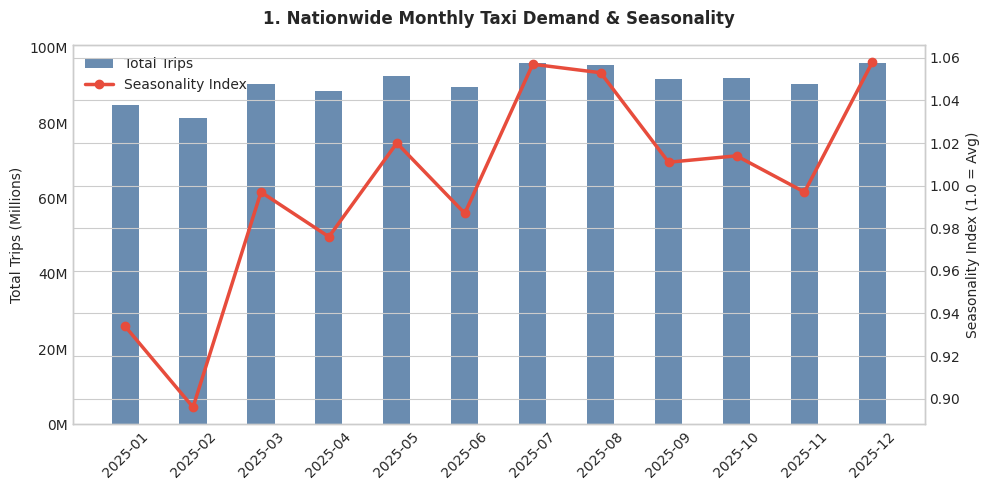

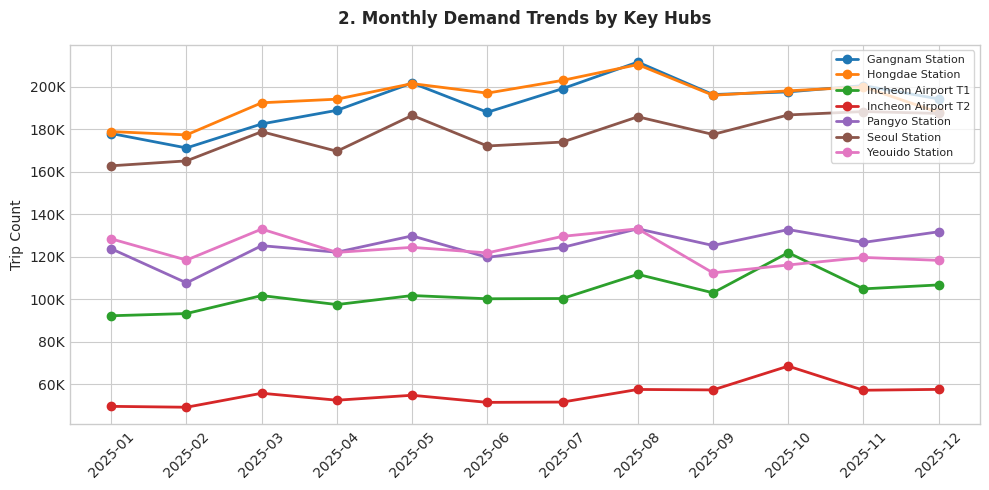

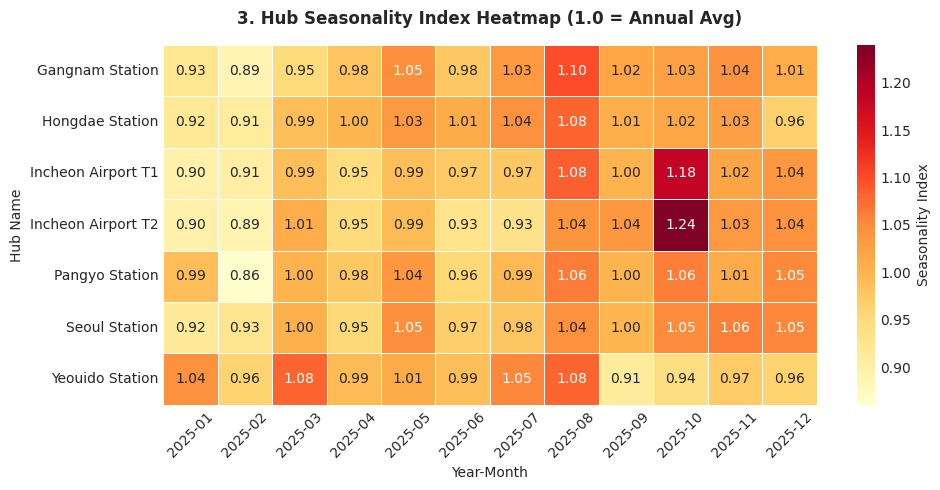

In [0]:
# ==========================================
# Visualization Settings
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# Data Load (Monthly Grid-Level)
# ==========================================
file_paths = sorted([
    os.path.join(base_dir, f) for f in os.listdir(base_dir)
    if unicodedata.normalize('NFC', f).startswith(prefix) and f.endswith('.csv')
])

li = []
for filename in file_paths:
    try:
        df_temp = pd.read_csv(filename, encoding='cp949')
    except UnicodeDecodeError:
        df_temp = pd.read_csv(filename, encoding='utf-8')
    li.append(df_temp)

df = pd.concat(li, axis=0, ignore_index=True)

# 2-1. Nationwide Monthly Total Aggregation
df_monthly_total = df.groupby('년월').agg(
    total_trips=('영업건수(건)', 'sum'),
    total_revenue=('영업금액(원)', 'sum')
).reset_index()

df_monthly_total['seasonality_index'] = (
    df_monthly_total['total_trips'] / df_monthly_total['total_trips'].mean()
).round(3)

# 2-2. Target Hub Aggregation
df_target = df[df['500미터격자'].isin(target_grids.keys())].copy()
df_target['hub_name'] = df_target['500미터격자'].map(target_grids)

piv_trips = df_target.pivot_table(
    index='년월', 
    columns='hub_name', 
    values='영업건수(건)', 
    aggfunc='sum'
).fillna(0)

df_hub_seasonality = piv_trips.apply(lambda x: x / x.mean(), axis=0).round(3)

# ==========================================
# Charts
# ==========================================

# ------------------------------------------
# Chart 1: Nationwide Demand & Seasonality Index (Dual-Axis)
# ------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1_twin = ax1.twinx()

months = df_monthly_total['년월']
total_trips = df_monthly_total['total_trips']

# Y-axis Formatter (Integer Millions - e.g., 40M, 14M)
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x*1e-6)}M' if (x*1e-6).is_integer() else f'{x*1e-6:.1f}M')
)

ax1.bar(months, total_trips, color='#2b5c8f', alpha=0.7, width=0.4, label='Total Trips')
ax1_twin.plot(months, df_monthly_total['seasonality_index'], color='#e74c3c', marker='o', linewidth=2.5, label='Seasonality Index')

ax1.set_title('1. Nationwide Monthly Taxi Demand & Seasonality', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Total Trips (Millions)')
ax1_twin.set_ylabel('Seasonality Index (1.0 = Avg)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(False)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart1_nationwide_demand.png', dpi=300)
plt.show()

# ------------------------------------------
# Chart 2: Hub Monthly Demand Trends
# ------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("tab10", len(piv_trips.columns))

# Y-axis Formatter (Thousands - K)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x*1e-3)}K'))

for i, col in enumerate(piv_trips.columns):
    ax2.plot(piv_trips.index, piv_trips[col], marker='o', label=col, linewidth=2, color=palette[i])

ax2.set_title('2. Monthly Demand Trends by Key Hubs', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('Trip Count')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right', fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig('chart2_hub_trends.png', dpi=300)
plt.show()

# ------------------------------------------
# Chart 3: Hub Seasonality Index Heatmap
# ------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 5))

sns.heatmap(
    df_hub_seasonality.T, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", 
    ax=ax3, 
    cbar_kws={'label': 'Seasonality Index'},
    linewidths=0.5
)

ax3.set_title('3. Hub Seasonality Index Heatmap (1.0 = Annual Avg)', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('Year-Month')
ax3.set_ylabel('Hub Name')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart3_seasonality_heatmap.png', dpi=300)
plt.show()


In [0]:
# ==========================================
# Phased Pricing Strategy
# Generated from the Assumptions section above.
# ==========================================
pricing_md = f"""
# 4. Price Logic

## Rationale
Pricing balances regulatory constraints, adoption barriers, and operating costs. Grounded in the official Seoul taxi fare baseline ({phase2_fare:,} KRW), the roadmap runs a 3-phase progression from penetration to monetization.

## Phase 1 — Market Entry (Launch – Month 6)
* **Objective**: Lower adoption barriers, secure initial volume.
* **Mechanics**: Penetration pricing at **{phase1_fare:,} KRW** (~{phase1_discount_pct}% below the {phase2_fare:,} KRW Seoul baseline); upfront flat quotes to remove surcharge anxiety.

## Phase 2 — Stabilization (Months 6–12)
* **Objective**: Reach market parity, optimize fleet efficiency at peak.
* **Mechanics**: Fares normalize to **{phase2_fare:,} KRW**; light surge (**{phase2_surge_range[0]}x-{phase2_surge_range[1]}x**) at peak hours or bad weather only.

## Phase 3 — Expansion & Retention (Months 12+)
* **Objective**: Maximize LTV, lock in recurring ridership.
* **Mechanics**: Monthly passes, fixed-route shuttle packages, tiered/premium options for frequent riders.

---

## Summary Table

| Phase | Timeline | Fare (vs. {phase2_fare:,} KRW standard) | Surge Policy | Focus |
| :--- | :--- | :--- | :--- | :--- |
| **Phase 1** | 0-6 months | **{phase1_fare:,} KRW** (-{phase1_discount_pct}%) | Flat, no surge | Drive trial volume |
| **Phase 2** | 6-12 months | **{phase2_fare:,} KRW** (parity) | Mild ({phase2_surge_range[0]}x-{phase2_surge_range[1]}x peak) | Yield optimization |
| **Phase 3** | 12+ months | Subscription / passes | Bundled / tiered | Retention & LTV |
"""

display(Markdown(pricing_md))



# 4. Price Logic

## Rationale
Pricing balances regulatory constraints, adoption barriers, and operating costs. Grounded in the official Seoul taxi fare baseline (4,800 KRW), the roadmap runs a 3-phase progression from penetration to monetization.

## Phase 1 — Market Entry (Launch – Month 6)
* **Objective**: Lower adoption barriers, secure initial volume.
* **Mechanics**: Penetration pricing at **4,000 KRW** (~16.7% below the 4,800 KRW Seoul baseline); upfront flat quotes to remove surcharge anxiety.

## Phase 2 — Stabilization (Months 6–12)
* **Objective**: Reach market parity, optimize fleet efficiency at peak.
* **Mechanics**: Fares normalize to **4,800 KRW**; light surge (**1.1x-1.3x**) at peak hours or bad weather only.

## Phase 3 — Expansion & Retention (Months 12+)
* **Objective**: Maximize LTV, lock in recurring ridership.
* **Mechanics**: Monthly passes, fixed-route shuttle packages, tiered/premium options for frequent riders.

---

## Summary Table

| Phase | Timeline | Fare (vs. 4,800 KRW standard) | Surge Policy | Focus |
| :--- | :--- | :--- | :--- | :--- |
| **Phase 1** | 0-6 months | **4,000 KRW** (-16.7%) | Flat, no surge | Drive trial volume |
| **Phase 2** | 6-12 months | **4,800 KRW** (parity) | Mild (1.1x-1.3x peak) | Yield optimization |
| **Phase 3** | 12+ months | Subscription / passes | Bundled / tiered | Retention & LTV |


# 5. Open Questions

The analysis above relies on several assumptions that remain unvalidated. Before committing capital, the following gaps would need to be closed:

**Regulatory & Legal**
* What is the realistic timeline for Level 4 autonomous driving permits in Seoul municipal roads? The current regulatory sandbox has geographic and speed restrictions that directly constrain TAM.
* How will insurance and liability be structured? Per-ride, per-vehicle, or operator-level coverage — and at what premium?
* Will autonomous ride-hailing require a separate business license category, or can it operate under existing taxi regulations?

**Consumer & Demand**
* What is the actual consumer willingness to ride in a driverless vehicle? Korean surveys show interest, but stated vs. revealed preference gaps are large in mobility.
* How does weather (monsoon season June-August, winter ice) affect both operational uptime and consumer willingness?
* Will nighttime operation be permitted, and will riders accept it? Night hours represent ~30% of taxi demand.

**Competitive Landscape**
* How will Kakao Mobility, Tmap, and existing taxi cooperatives respond? Regulatory lobbying, price matching, or partnership?
* Are other autonomous vehicle operators (domestic or international) targeting the same corridors?

**Operational & Financial**
* What is the realistic per-vehicle cost (CAPEX + maintenance + remote monitoring) and how does it compare to driver labor costs?
* What fleet utilization rate is achievable in Year 1 with geofenced operations? Our 10-20 trips/day range is assumed, not measured.
* Charging/refueling infrastructure availability along target corridors — particularly for airport shuttle routes.

**Data Limitations**
* The 2025 taxi operations data captures *human-driven* taxi patterns. Autonomous vehicle routing, speed, and demand patterns may differ significantly.
* Grid-level data (500m resolution) does not capture trip origin-destination pairs — we cannot validate corridor-level demand without OD matrix data.
* Addressable share (10-35%) is an assumption bracket, not derived from road-readiness or regulatory assessment.